# Simulation of a **pin** silicon solar cell

The following code loads the needed modules.

In [1]:
import numpy as np

import matplotlib.pyplot as plt

from synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, hole_current_density, electron_current_density

import synumses.one_dimension.parameters as parameters

from synumses.one_dimension.functions import calc_p_density, calc_n_density, calc_recombination

import synumses.one_dimension.solver as solver

## Definition of the pin solar cell
The silicon has a thickness of $l_\mathrm{x}=1\,\mathrm{\mu m}$.<br>
The p-doping is $50\,\mathrm{nm}$, the i-region is $900\,\mathrm{nm}$, and the  n-doping is $50\,\mathrm{nm}$ thick.<br>
There is no recombination.

In [2]:
parameters.n = 1000
parameters.lx = 1000E-9

parameters.init_geometry()

#parameters.Cau = 0*1E-24

Na = 1.0E24
Nd = 1.0E24

Eg = 1.12

# pn transistion at x1
x1 =  50E-9
x2 = 950E-9

for i in range(0, parameters.n):
    
    parameters.Ec[i] = Eg
    parameters.Ev[i] = 0.0
    parameters.C[i]  = 0.0
    
    if parameters.pos_x[i] < x1:      
        parameters.C[i]  = -Na
        
    if parameters.pos_x[i] > x2:       
        parameters.C[i]  = Nd

Now, we plot the default band diagramm and the doping levels

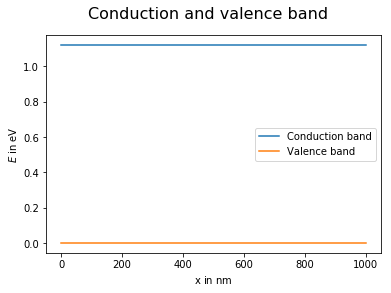

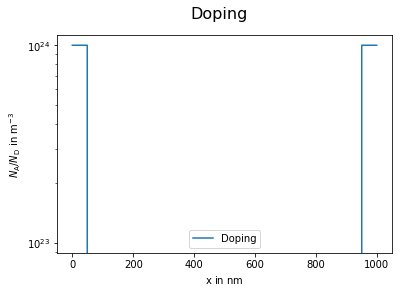

In [3]:
# Band diagramm
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence band", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.Ec, label='Conduction band')
axis.plot(parameters.pos_x * 1E9, parameters.Ev, label='Valence band')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$E$ in $\mathrm{eV}$")

axis.legend()
plt.show()

# Doping level
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Doping", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, np.abs(parameters.C), label='Doping')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$N_\mathrm{A} / N_\mathrm{D}$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


## Solving without biasing
Now, let's apply a voltage of $0\,\mathrm{mV}$!.

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


Norm of b:  0.16545144913864437
Norm of x: 1.7143481241371167e-12


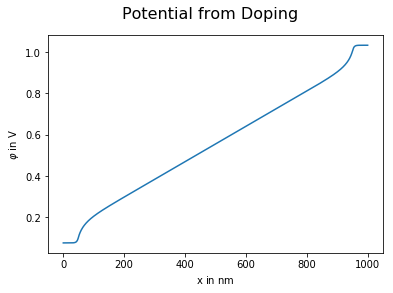

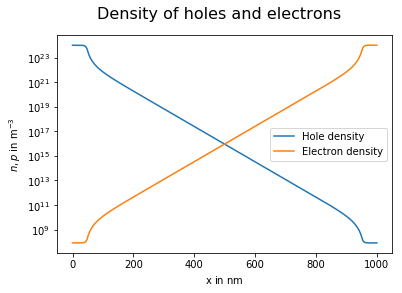

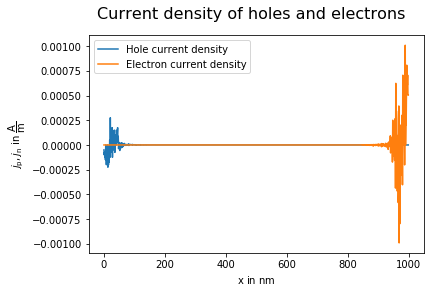

In [4]:
parameters.init_potential()
solver.solve_no_bias()
bias_point = 0.0

solver.solve_bias(bias_point,0)

# Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from Doping", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3], label='Potential')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

plt.show()

#
# Plot electron and hole density
#
calc_p_density()
calc_n_density()
p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$n,p$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


# Electron and hole current density 
j_p =     hole_current_density()
j_n = electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(j_p, label='Hole current density')
axis.plot(j_n, label='Electron current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
plt.show()

## Simulation with illumination
Now we illuminate the solar cell and simulate the short circuit current density.<br>
We assume a powerdensity of $1\,\mathrm{\dfrac{kW}{m^3}}$,
an absorption coefficient for silicon of $\alpha_\mathrm{Si} = 2.0\cdot 10^{6}\,\mathrm{m^{-1}}$, and
a light efficiency of $\eta = 0.6$. <br>
For the simulation to converge, the illumination must be ramped up, this takes some time.<br>


In [5]:
# For the simulatoin the illumination starts
# 10nm after and stops 10nm before the contacts.
x1 = 10E-9
x2 = 990E-9


bias_point = 0.0

eta = 0.6

I0 = 1E3

alpha = 2E6

dI0 = alpha*I0*eta

steps = 23

for i in range(steps):

    print("Step:", i,
          "Generation rate at the surface",
          dI0/(2**steps) * 2**(i+1) /(parameters.q * Eg))

    parameters.generation = np.where((parameters.pos_x  > x1) & (parameters.pos_x < x2),
                                     dI0/(2**steps) * 2**(i+1) * np.exp(-parameters.pos_x*alpha) /(parameters.q * Eg),
                                     0)

    solver.solve_bias(-bias_point,0)
    
    j = np.mean(hole_current_density() + electron_current_density())
    
    print("\t Current density:", j)
    

Step: 0 Generation rate at the surface 1.596552985055106e+21
Norm of b:  0.00411510467496992
Norm of x: 0.24729896525331724
Norm of b:  0.0029843163288667766
Norm of x: 0.066451274286413
Norm of b:  0.003887045578955082
Norm of x: 0.01754039698517272
Norm of b:  0.003595556045202748
Norm of x: 0.0012983809501607593
Norm of b:  0.0038479314706266047
Norm of x: 7.70911572678309e-06
Norm of b:  0.003633406334760488
Norm of x: 3.1626325953998444e-10
	 Current density: -9.094959979159488e-05
Step: 1 Generation rate at the surface 3.193105970110212e+21
Norm of b:  0.002877643032725877
Norm of x: 0.12107608726266463
Norm of b:  0.003186821535755296
Norm of x: 0.020848832172760193
Norm of b:  0.004349512793085392
Norm of x: 0.0011549840128720326
Norm of b:  0.003814726358590548
Norm of x: 4.31025169421815e-06
Norm of b:  0.0036211674994484078
Norm of x: 7.249463279500172e-11
	 Current density: -0.00017592199955442328
Step: 2 Generation rate at the surface 6.386211940220424e+21
Norm of b:  0.00

## Plot the parameters with illumination
* generation rate,
* hole and electron density, and
* hole and electron current density.

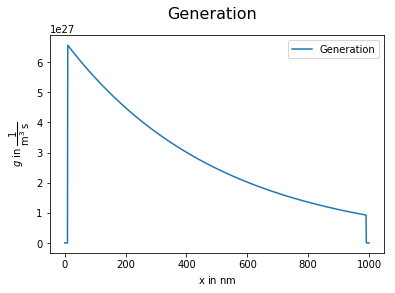

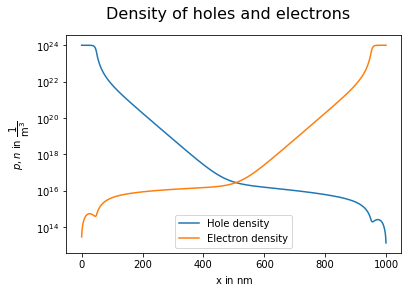

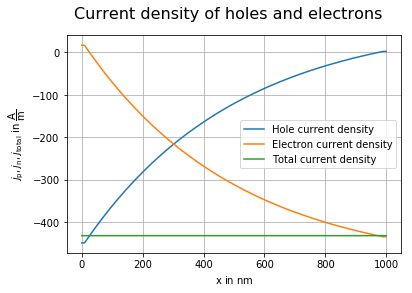

In [6]:
# Generation
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Generation", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.generation, label='Generation')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$g$ in $\mathrm{\dfrac{1}{m^3\, s}}$")

axis.legend()
plt.show()

# Hole and electron density
calc_p_density()
calc_n_density()

p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.semilogy(parameters.pos_x * 1E9, p, label='Hole density')
axis.semilogy(parameters.pos_x * 1E9, n, label='Electron density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$p, n$ in $\mathrm{\dfrac{1}{m^3}}$")

axis.legend()
plt.show()


# Hole and electron current density 
j_p =     hole_current_density()
j_n =     electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')
axis.plot(parameters.pos_x * 1E9, j_n+j_p, label='Total current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}, j_\mathrm{total}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
axis.grid()
plt.show()

## Voltage sweep
Now, the voltage is swept to get the characteristics of the solar cell for illumination

In [7]:
u_start = 0.0
u_stop  = 0.50
u_step  = 0.025

voltage = []
current_density = []

bias_points = np.linspace(u_start, u_stop, int((u_stop-u_start)/u_step) + 2)
for bias_point in bias_points:

    solver.solve_bias(bias_point,0)   
    
    j = np.mean(hole_current_density() + electron_current_density())
    voltage.append(bias_point)
    current_density.append(j)
    print(bias_point, ",", j)
  

Norm of b:  0.0028824684010202235
Norm of x: 1.574111923322945e-13
0.0 , -431.6296787653856
Norm of b:  171428389153.36392
Norm of x: 0.8193746137183825
Norm of b:  45303.31346459132
Norm of x: 0.0074639773960513715
Norm of b:  0.047458315322624206
Norm of x: 6.740099649658524e-05
Norm of b:  0.00424349347275788
Norm of x: 1.2332206945660723e-08
0.023809523809523808 , -431.5981527184161
Norm of b:  171428389285.1726
Norm of x: 0.8242079334071774
Norm of b:  53161.102732181804
Norm of x: 0.010928226715868442
Norm of b:  0.06076706830138463
Norm of x: 7.569518418607958e-05
Norm of b:  0.0034924850860392335
Norm of x: 1.3202215441796333e-08
0.047619047619047616 , -431.56557797477626
Norm of b:  171428389412.98895
Norm of x: 0.8233212229196503
Norm of b:  45249.8866538277
Norm of x: 0.008907138441703816
Norm of b:  0.055944839567276465
Norm of x: 9.069825694134323e-05
Norm of b:  0.0039290859045370725
Norm of x: 1.5283428717471747e-08
0.07142857142857142 , -431.5319097623493
Norm of b:  17

# Plot the characteristic 
* the current density and 
* the power density.

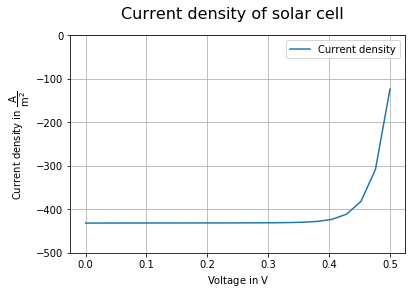

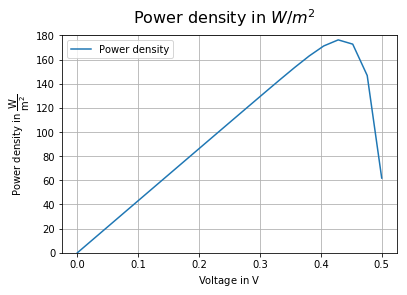

In [10]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of solar cell", fontsize=16)

axis.plot(voltage, current_density, label='Current density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Current density in $\mathrm{\dfrac{A}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(-500,0)
plt.show()


# Power density
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Power density in $W/m^2$", fontsize=16)

axis.plot(voltage, -np.array(current_density)*np.array(voltage), label='Power density')

axis.set_xlabel(r"Voltage in $\mathrm{V}$")
axis.set_ylabel(r"Power density in $\mathrm{\dfrac{W}{m^2}}$")

axis.legend()
axis.grid()
plt.ylim(0,180)
plt.show()